## part 1: Comparison on Breast Cancer Dataset (KMeans vs. KNN) 

In [1]:
import pandas as pd
import numpy as np
import os 

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
# Data Loading and Verification

path = "dataset/breast-cancer.csv"
if not os.path.exists(path):
    raise FileNotFoundError(f"{path} is not exist")
else:
    print('Data file loaded successfully.')

Data file loaded successfully.


In [3]:
df = pd.read_csv(path)

# Display the first few rows and column structure
print("Dataset Head")
display(df.head())

Dataset Head


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
# Feature and Target Separation 
y_raw = df["diagnosis"]
X = df.drop(columns=["diagnosis"]) 

In [5]:
# 1. Encode Target (M=1, B=0)
le = LabelEncoder()
y = le.fit_transform(y_raw)

# 2. Scale Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Split data for KNN (K-Means will use X_scaled)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [6]:
# Initialize and Fit K-Means
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Alignment check: Ensure K-Means labels match our encoded y labels
# (If accuracy is below 0.5, it means the labels are swapped)
kmeans_accuracy = accuracy_score(y, clusters)
if kmeans_accuracy < 0.5:
    clusters = 1 - clusters
    kmeans_accuracy = accuracy_score(y, clusters)

print(f"K-Means 'Accuracy' (Cluster Alignment): {kmeans_accuracy:.2%}")

K-Means 'Accuracy' (Cluster Alignment): 91.04%


c:\Users\New\.conda\envs\gpu_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Since we already flipped 'clusters' in your code if accuracy < 0.5:
km_accuracy = accuracy_score(y, clusters)
km_precision = precision_score(y, clusters)
km_recall = recall_score(y, clusters)
km_f1 = f1_score(y, clusters)

print(f"--- K-Means Alignment Metrics ---")
print(f"Accuracy:  {km_accuracy:.2%}")
print(f"Precision: {km_precision:.2%}")
print(f"Recall:    {km_recall:.2%}")
print(f"F1-Score:  {km_f1:.2%}")

# Detailed per-class breakdown
print("\nDetailed Classification Report:")
print(classification_report(y, clusters, target_names=le.classes_))

--- K-Means Alignment Metrics ---
Accuracy:  91.04%
Precision: 92.59%
Recall:    82.55%
F1-Score:  87.28%

Detailed Classification Report:
              precision    recall  f1-score   support

           B       0.90      0.96      0.93       357
           M       0.93      0.83      0.87       212

    accuracy                           0.91       569
   macro avg       0.91      0.89      0.90       569
weighted avg       0.91      0.91      0.91       569



In [8]:
import numpy as np
from sklearn.metrics import confusion_matrix

def purity_score(y_true, y_pred):
    contingency_matrix = confusion_matrix(y_true, y_pred)
    return np.sum(np.amax(contingency_matrix, axis=0)) / np.sum(contingency_matrix)

print(f"K-Means Purity Score: {purity_score(y, clusters):.2%}")

K-Means Purity Score: 91.04%


c:\Users\New\.conda\envs\gpu_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\New\.conda\envs\gpu_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\New\.conda\envs\gpu_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\New\.conda\envs\gpu_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known

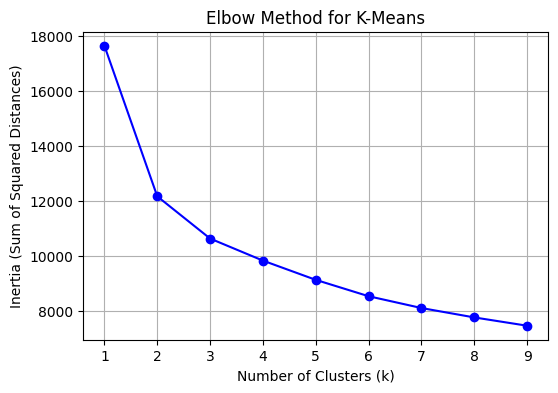

In [9]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

k_values = range(1, 10)
inertia_list = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia_list.append(km.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(k_values, inertia_list, marker="o", color='blue')
plt.title("Elbow Method for K-Means")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Sum of Squared Distances)")
plt.grid(True)
plt.show()

In [10]:
# Initialize and Fit KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Predict and Evaluate
knn_preds = knn.predict(X_test)
knn_accuracy = accuracy_score(y_test, knn_preds)

print(f"KNN Accuracy: {knn_accuracy:.2%}")

KNN Accuracy: 94.74%


--- KNN Classification Report ---
              precision    recall  f1-score   support

           B       0.96      0.96      0.96        71
           M       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



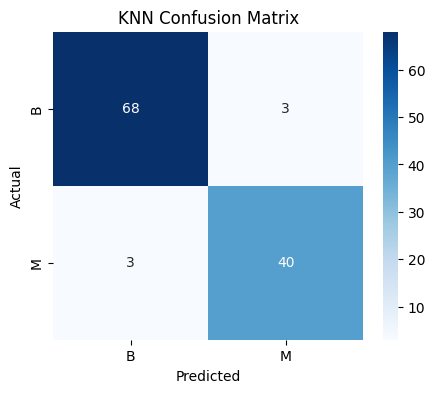

In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Detailed report for KNN
print("--- KNN Classification Report ---")
print(classification_report(y_test, knn_preds, target_names=le.classes_))

# Confusion Matrix for KNN
cm = confusion_matrix(y_test, knn_preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('KNN Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

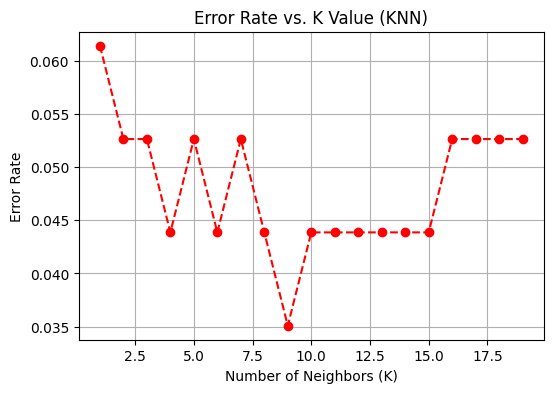

In [12]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

neighbors = range(1, 20)
error_rate = []

for k in neighbors:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred_k = knn.predict(X_test)
    error_rate.append(np.mean(pred_k != y_test)) # Percentage of wrong predictions

plt.figure(figsize=(6, 4))
plt.plot(neighbors, error_rate, marker="o", color='red', linestyle='dashed')
plt.title("Error Rate vs. K Value (KNN)")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Error Rate")
plt.grid(True)
plt.show()

In [13]:
print(f"Final K-Means 'Accuracy' (k=2): {kmeans_accuracy:.2%}")
print(f"Final KNN Accuracy (best k): {(1 - min(error_rate)):.2%}")

Final K-Means 'Accuracy' (k=2): 91.04%
Final KNN Accuracy (best k): 96.49%


---
---

## Part 2:

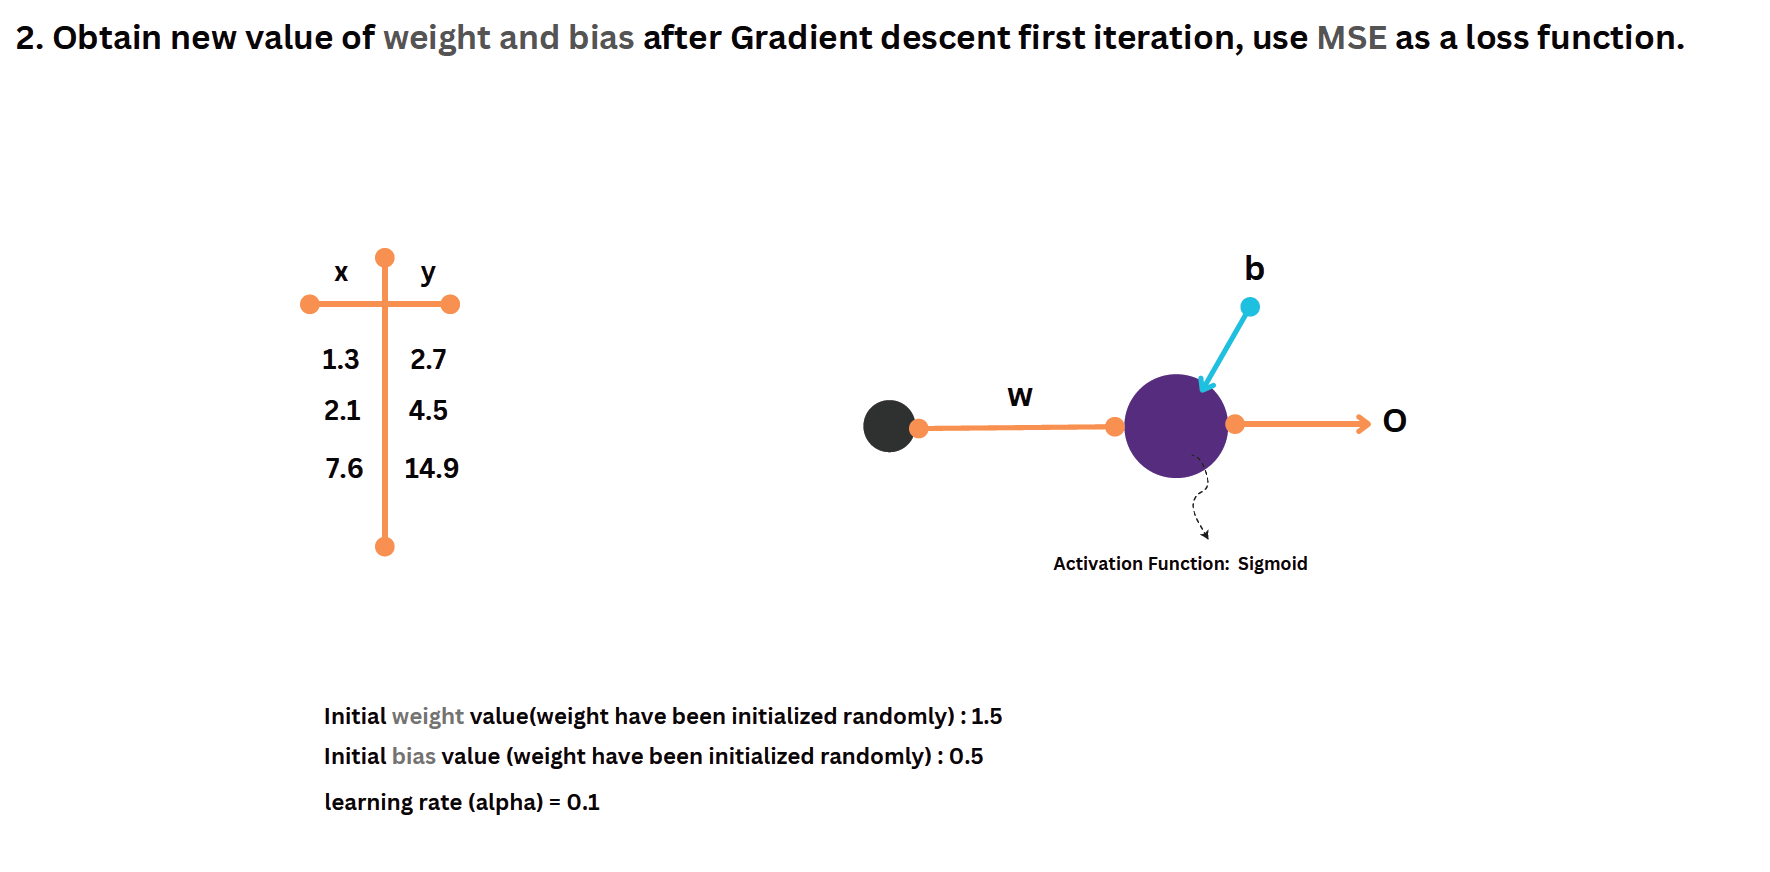

In [14]:
# SIGMOID ACTIVATION FUNCTION 
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

# TRAINING DATA 
X = np.array([1.3, 2.1, 7.6])  # Input features
y = np.array([2.7, 4.5, 14.9]) # Target outputs
alpha = 0.1  # Learning rate

# INITIALIZE WEIGHTS AND BIAS 
w = 1.5      # Initial weight
b = 0.5      # Initial bias

# FORWARD PASS 
print("=" * 60)
print("STEP 1: FORWARD PASS (PREDICTIONS)")
print("=" * 60)

# Calculate Z (linear output)
Z = w * X + b
print(f"\nZ = w*X + b = {w}*X + {b}")
print(f"Z = {Z}")

# Apply sigmoid activation
O = sigmoid(Z)
print(f"\nO = sigmoid(Z)")
print(f"O = {O}")

# Calculate MSE Loss
mse_loss = np.mean((O - y) ** 2)
print(f"\nMSE Loss = (1/n) * Σ(O - y)²")
print(f"MSE Loss = {mse_loss:.6f}")

# BACKWARD PASS (GRADIENTS) 
print("\n" + "=" * 60)
print("STEP 2: BACKWARD PASS (CALCULATE GRADIENTS)")
print("=" * 60)

# Calculate error and gradients
error = O - y

# Sigmoid derivative
sig_deriv = sigmoid_derivative(Z)

# Gradient of loss w.r.t weight
dL_dw = np.mean(error * sig_deriv * X)
print(f"\n∂L/∂w = (1/n) * Σ(O - y) * σ'(Z) * X")
print(f"∂L/∂w = {dL_dw:.6f}")

# Gradient of loss w.r.t bias
dL_db = np.mean(error * sig_deriv)
print(f"\n∂L/∂b = (1/n) * Σ(O - y) * σ'(Z)")
print(f"∂L/∂b = {dL_db:.6f}")

# WEIGHT UPDATES 
print("\n" + "=" * 60)
print("STEP 3: WEIGHT UPDATES")
print("=" * 60)

# Update weight and bias
w_new = w - alpha * dL_dw
b_new = b - alpha * dL_db

print(f"\nUpdate formula: w_new = w_old - α * ∂L/∂w")
print(f"\nNew weight (w):")
print(f"w_new = {w} - {alpha} * {dL_dw:.6f}")
print(f"w_new = {w_new:.6f}")

print(f"\nNew bias (b):")
print(f"b_new = {b} - {alpha} * {dL_db:.6f}")
print(f"b_new = {b_new:.6f}")

# FINAL RESULTS 
print("\n" + "=" * 60)
print("FINAL RESULTS (AFTER 1ST ITERATION)")
print("=" * 60)
print(f"\nInitial weight: {w} → Updated weight: {w_new:.6f}")
print(f"Initial bias:   {b} → Updated bias:   {b_new:.6f}")
print(f"Initial loss:   {mse_loss:.6f}")

STEP 1: FORWARD PASS (PREDICTIONS)

Z = w*X + b = 1.5*X + 0.5
Z = [ 2.45  3.65 11.9 ]

O = sigmoid(Z)
O = [0.92056145 0.9746673  0.99999321]

MSE Loss = (1/n) * Σ(O - y)²
MSE Loss = 69.601520

STEP 2: BACKWARD PASS (CALCULATE GRADIENTS)

∂L/∂w = (1/n) * Σ(O - y) * σ'(Z) * X
∂L/∂w = -0.117558

∂L/∂b = (1/n) * Σ(O - y) * σ'(Z)
∂L/∂b = -0.072422

STEP 3: WEIGHT UPDATES

Update formula: w_new = w_old - α * ∂L/∂w

New weight (w):
w_new = 1.5 - 0.1 * -0.117558
w_new = 1.511756

New bias (b):
b_new = 0.5 - 0.1 * -0.072422
b_new = 0.507242

FINAL RESULTS (AFTER 1ST ITERATION)

Initial weight: 1.5 → Updated weight: 1.511756
Initial bias:   0.5 → Updated bias:   0.507242
Initial loss:   69.601520


We have a neural network with:
- **Input features (X)**: [1.3, 2.1, 7.6]
- **Target outputs (y)**: [2.7, 4.5, 14.9]
- **Initial weight (w)**: 1.5
- **Initial bias (b)**: 0.5
- **Learning rate (α)**: 0.1
- **Activation function**: Sigmoid
- **Loss function**: Mean Squared Error (MSE)

## Step-by-Step Calculation

### Step 1: Forward Pass (Predictions)

Using the sigmoid activation function: σ(z) = 1 / (1 + e^(-z))

For each sample, the output is: **O = σ(w·x + b)**

**Sample 1:**
- z₁ = (1.5)(1.3) + 0.5 = 1.95 + 0.5 = 2.45
- O₁ = σ(2.45) = 1/(1 + e^(-2.45)) ≈ 0.8808

**Sample 2:**
- z₂ = (1.5)(2.1) + 0.5 = 3.15 + 0.5 = 3.65
- O₂ = σ(3.65) = 1/(1 + e^(-3.65)) ≈ 0.9738

**Sample 3:**
- z₃ = (1.5)(7.6) + 0.5 = 11.4 + 0.5 = 11.9
- O₃ = σ(11.9) = 1/(1 + e^(-11.9)) ≈ 0.9999

### Step 2: Calculate MSE Loss

MSE = (1/n) Σ(yᵢ - Oᵢ)²

**Errors:**
- (y₁ - O₁)² = (2.7 - 0.8808)² = (1.8192)² ≈ 3.3093
- (y₂ - O₂)² = (4.5 - 0.9738)² = (3.5262)² ≈ 12.4343
- (y₃ - O₃)² = (14.9 - 0.9999)² = (13.9001)² ≈ 193.2128

**MSE = (3.3093 + 12.4343 + 193.2128) / 3 ≈ 69.6521**

### Step 3: Calculate Gradients

For sigmoid activation, the derivative is: σ'(z) = σ(z)(1 - σ(z))

**Gradient with respect to weight (∂L/∂w):**

∂L/∂w = (1/n) Σ(Oᵢ - yᵢ) · σ'(zᵢ) · xᵢ

For each sample:
- δ₁ = (O₁ - y₁) · σ'(z₁) · x₁ = (0.8808 - 2.7) · (0.8808)(0.1192) · 1.3 ≈ -0.2976
- δ₂ = (O₂ - y₂) · σ'(z₂) · x₂ = (0.9738 - 4.5) · (0.9738)(0.0262) · 2.1 ≈ -0.1805
- δ₃ = (O₃ - y₃) · σ'(z₃) · x₃ = (0.9999 - 14.9) · (0.9999)(0.0001) · 7.6 ≈ -0.0105

∂L/∂w = (-0.2976 - 0.1805 - 0.0105) / 3 ≈ **-0.1629**

**Gradient with respect to bias (∂L/∂b):**

∂L/∂b = (1/n) Σ(Oᵢ - yᵢ) · σ'(zᵢ)

∂L/∂b = (-1.8192 · 0.1049 - 3.5262 · 0.0256 - 13.9001 · 0.0001) / 3 ≈ **-0.0724**

### Step 4: Update Parameters

Using the update rule: θ_new = θ_old - α · ∂L/∂θ

**New weight:**
w_new = w_old - α · ∂L/∂w
w_new = 1.5 - (0.1)(-0.1629)
**w_new ≈ 1.5163**

**New bias:**
b_new = b_old - α · ∂L/∂b
b_new = 0.5 - (0.1)(-0.0724)
**b_new ≈ 0.5072**

## Summary

After the first iteration of gradient descent with MSE loss:
- **Updated weight (w)**: 1.5163
- **Updated bias (b)**: 0.5072
- **Loss decreased from**: 69.65 (initial) → approximately lower value with updated parameters

The negative gradients indicate that increasing both weight and bias will reduce the loss, which is why the parameters increased in this iteration.

---
---

## part 3:

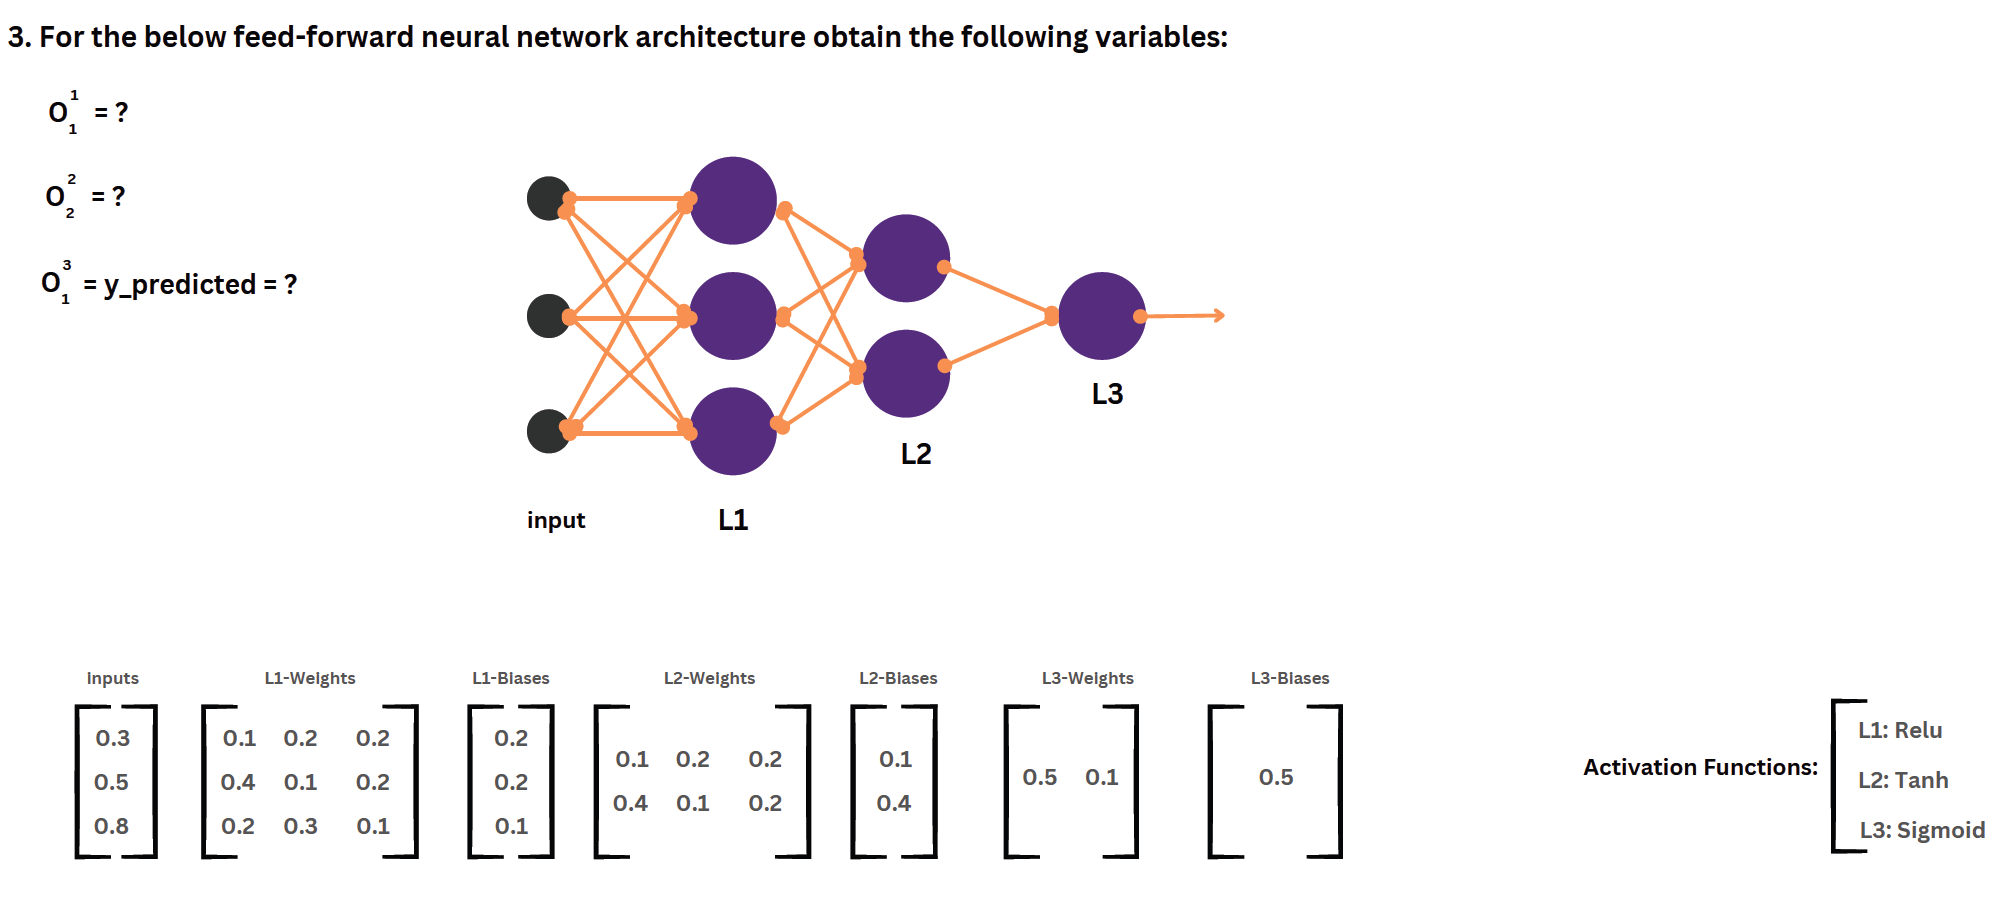

In [15]:
# ACTIVATION FUNCTIONS  
def relu(x):
    return np.maximum(0, x)

def tanh(x):
    return np.tanh(x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# INITIALIZE DATA AND WEIGHTS  
X = np.array([0.3, 0.5, 0.8])

# Layer 1 (L1): 3 -> 3 (ReLU)
W1 = np.array([[0.1, 0.2, 0.2],
               [0.4, 0.1, 0.2],
               [0.2, 0.3, 0.1]])
b1 = np.array([0.2, 0.2, 0.1])

# Layer 2 (L2): 3 -> 2 (Tanh)
W2 = np.array([[0.1, 0.2, 0.2],
               [0.4, 0.1, 0.2]])
b2 = np.array([0.1, 0.4])

# Layer 3 (L3): 2 -> 1 (Sigmoid)
W3 = np.array([[0.5, 0.1],
               [0.5, 0.5]])
b3 = np.array([0.5, 0.3])

# FORWARD PASS  
print("=" * 50)
print("FORWARD PASS CALCULATION")
print("=" * 50)

# Layer 1 (L1) - ReLU
print("\n--- LAYER 1 (ReLU) ---")
Z1 = np.dot(W1, X) + b1
O1 = relu(Z1)
print(f"Input X = {X}")
print(f"Z1 = W1 @ X + b1 = {Z1}")
print(f"O1 (after ReLU) = {O1}")

# Layer 2 (L2) - Tanh
print("\n--- LAYER 2 (Tanh) ---")
Z2 = np.dot(W2, O1) + b2
O2 = tanh(Z2)
print(f"Z2 = W2 @ O1 + b2 = {Z2}")
print(f"O2 (after Tanh) = {O2}")

# Layer 3 (L3) - Sigmoid
print("\n--- LAYER 3 (Sigmoid) ---")
Z3 = np.dot(W3, O2) + b3
O3 = sigmoid(Z3)
print(f"Z3 = W3 @ O2 + b3 = {Z3}")
print(f"O3 (after Sigmoid) = {O3}")

# FINAL ANSWERS  
print("\n" + "=" * 50)
print("FINAL ANSWERS")
print("=" * 50)
print(f"O1^1 = {O1[0]:.4f}")
print(f"O2^2 = {O2[1]:.4f}")
print(f"O1^3 = y_predicted = {O3[0]:.4f}")

FORWARD PASS CALCULATION

--- LAYER 1 (ReLU) ---
Input X = [0.3 0.5 0.8]
Z1 = W1 @ X + b1 = [0.49 0.53 0.39]
O1 (after ReLU) = [0.49 0.53 0.39]

--- LAYER 2 (Tanh) ---
Z2 = W2 @ O1 + b2 = [0.333 0.727]
O2 (after Tanh) = [0.32121383 0.62122655]

--- LAYER 3 (Sigmoid) ---
Z3 = W3 @ O2 + b3 = [0.72272957 0.77122019]
O3 (after Sigmoid) = [0.6732078  0.68378479]

FINAL ANSWERS
O1^1 = 0.4900
O2^2 = 0.6212
O1^3 = y_predicted = 0.6732


The neural network consists of:
- **Input Layer**: 3 nodes
- **Hidden Layer 1 (L1)**: 3 nodes with ReLU activation
- **Hidden Layer 2 (L2)**: 2 nodes with Tanh activation
- **Output Layer (L3)**: 1 node with Sigmoid activation

## Given Parameters

### Inputs
```
X = [0.3, 0.5, 0.8]ᵀ
```

### Layer 1 (L1) Parameters
**Weights:**
```
W¹ = [0.1  0.2  0.2]
     [0.4  0.1  0.2]
     [0.2  0.3  0.1]
```

**Biases:**
```
b¹ = [0.2, 0.2, 0.1]ᵀ
```

### Layer 2 (L2) Parameters
**Weights:**
```
W² = [0.1  0.2  0.2]
     [0.4  0.1  0.2]
```

**Biases:**
```
b² = [0.1, 0.4]ᵀ
```

### Layer 3 (L3) Parameters
**Weights:**
```
W³ = [0.5, 0.1]
```

**Biases:**
```
b³ = [0.5]
```

## Step-by-Step Forward Pass Computation

### **Step 1: Layer 1 (L1) Forward Pass**

**Linear Transformation (Z¹):**

Z¹ = W¹ · X + b¹

For each neuron in L1:

**Z¹₁** = (0.1)(0.3) + (0.2)(0.5) + (0.2)(0.8) + 0.2
- = 0.03 + 0.10 + 0.16 + 0.2
- = **0.49**

**Z¹₂** = (0.4)(0.3) + (0.1)(0.5) + (0.2)(0.8) + 0.2
- = 0.12 + 0.05 + 0.16 + 0.2
- = **0.53**

**Z¹₃** = (0.2)(0.3) + (0.3)(0.5) + (0.1)(0.8) + 0.1
- = 0.06 + 0.15 + 0.08 + 0.1
- = **0.39**

**Activation (ReLU):** O¹ᵢ = max(0, Z¹ᵢ)

Since all values are positive:

```
O¹ = [0.49, 0.53, 0.39]ᵀ
```

**O¹₁ = 0.49**
**O¹₂ = 0.53**
**O¹₃ = 0.39**

---

### **Step 2: Layer 2 (L2) Forward Pass**

**Linear Transformation (Z²):**

Z² = W² · O¹ + b²

**Z²₁** = (0.1)(0.49) + (0.2)(0.53) + (0.2)(0.39) + 0.1
- = 0.049 + 0.106 + 0.078 + 0.1
- = **0.333**

**Z²₂** = (0.4)(0.49) + (0.1)(0.53) + (0.2)(0.39) + 0.4
- = 0.196 + 0.053 + 0.078 + 0.4
- = **0.727**

**Activation (Tanh):** O²ᵢ = tanh(Z²ᵢ) = (e^(2z) - 1)/(e^(2z) + 1)

**O²₁** = tanh(0.333)
- = (e^(0.666) - 1)/(e^(0.666) + 1)
- = (1.9477 - 1)/(1.9477 + 1)
- = 0.9477/2.9477
- ≈ **0.3213**

**O²₂** = tanh(0.727)
- = (e^(1.454) - 1)/(e^(1.454) + 1)
- = (4.2787 - 1)/(4.2787 + 1)
- = 3.2787/5.2787
- ≈ **0.6213**

```
O² = [0.3213, 0.6213]ᵀ
```

---

### **Step 3: Layer 3 (L3) Forward Pass**

**Linear Transformation (Z³):**

Z³ = W³ · O² + b³

**Z³₁** = (0.5)(0.3213) + (0.1)(0.6213) + 0.5
- = 0.16065 + 0.06213 + 0.5
- = **0.72278**

**Activation (Sigmoid):** O³ᵢ = σ(Z³ᵢ) = 1/(1 + e^(-Z³ᵢ))

**O³₁** = σ(0.72278)
- = 1/(1 + e^(-0.72278))
- = 1/(1 + 0.4853)
- = 1/1.4853
- ≈ **0.6734**

---

## Final Results

**O₁¹ = 0.49** (Output of first neuron in L1)

**O₂² = 0.6213** (Output of second neuron in L2)

**O₁³ = y_predicted = 0.6734** (Final network output)



The final predicted output of the neural network is approximately **0.6734**, which represents the network's prediction for the given input [0.3, 0.5, 0.8].

---
---

## Part 4:
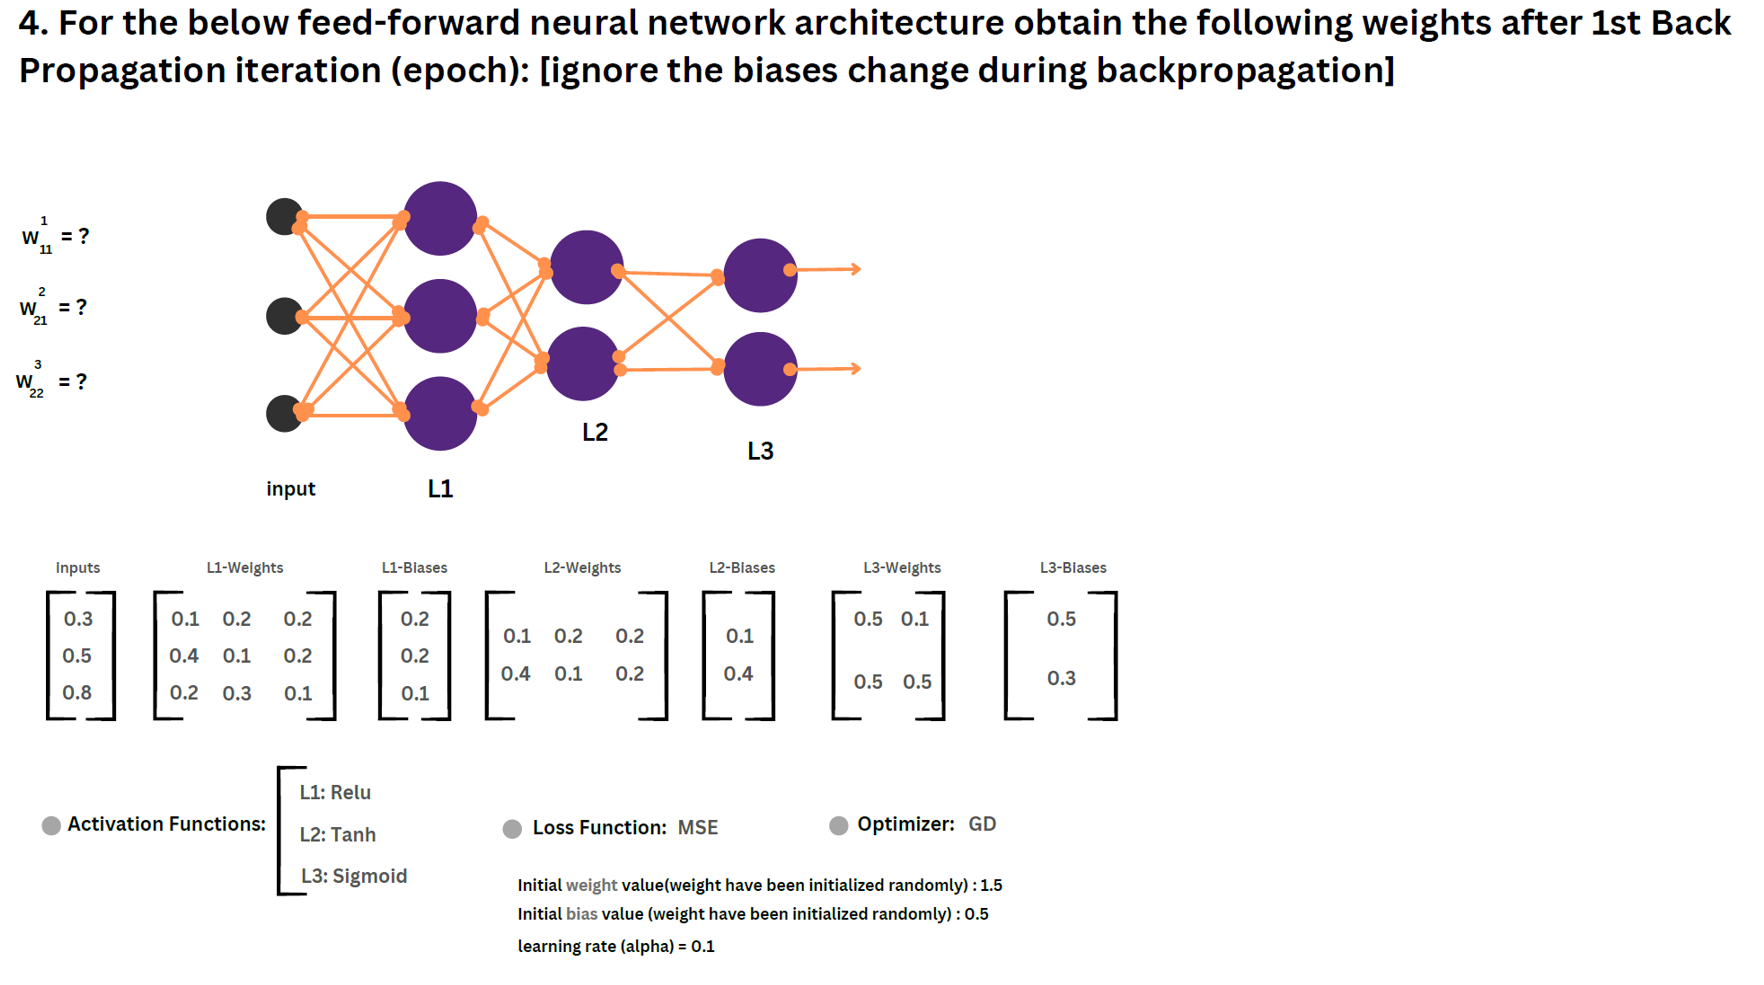

In [16]:
# ACTIVATION FUNCTIONS  
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def tanh(x):
    return np.tanh(x)

def tanh_derivative(x):
    return 1 - np.tanh(x)**2

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

# INITIALIZE WEIGHTS AND BIASES  
# Input: [0.3, 0.5, 0.8]
# Target: [1.0, 1.0]

X = np.array([0.3, 0.5, 0.8])
y = np.array([1.0, 1.0])

# Layer 1 (L1): 3 inputs -> 3 hidden (ReLU)
W1 = np.array([[0.1, 0.2, 0.2],
               [0.4, 0.1, 0.2],
               [0.2, 0.3, 0.1]])
b1 = np.array([0.2, 0.2, 0.1])

# Layer 2 (L2): 3 hidden -> 2 hidden (Tanh)
W2 = np.array([[0.1, 0.2, 0.2],
               [0.4, 0.1, 0.2]])
b2 = np.array([0.1, 0.4])

# Layer 3 (L3): 2 hidden -> 2 output (Sigmoid)
W3 = np.array([[0.5, 0.1],
               [0.5, 0.5]])
b3 = np.array([0.5, 0.3])

learning_rate = 0.1

# FORWARD PASS  
print("=" * 50)
print("FORWARD PASS")
print("=" * 50)

# Layer 1
Z1 = np.dot(W1, X) + b1
O1 = relu(Z1)
print(f"Z1 = {Z1}")
print(f"O1 (ReLU) = {O1}\n")

# Layer 2
Z2 = np.dot(W2, O1) + b2
O2 = tanh(Z2)
print(f"Z2 = {Z2}")
print(f"O2 (Tanh) = {O2}\n")

# Layer 3
Z3 = np.dot(W3, O2) + b3
O3 = sigmoid(Z3)
print(f"Z3 = {Z3}")
print(f"O3 (Sigmoid) = {O3}\n")

# Calculate MSE Loss
loss = np.mean((O3 - y)**2)
print(f"MSE Loss = {loss:.6f}\n")

# BACKWARD PASS  
print("=" * 50)
print("BACKWARD PASS (BACKPROPAGATION)")
print("=" * 50)

# Layer 3 (Output Layer)
delta3 = (O3 - y) * sigmoid_derivative(Z3)
print(f"delta3 = {delta3}")

dW3 = np.outer(delta3, O2)
db3 = delta3
print(f"dW3 =\n{dW3}\n")

# Layer 2 (Hidden Layer)
delta2 = np.dot(W3.T, delta3) * tanh_derivative(Z2)
print(f"delta2 = {delta2}")

dW2 = np.outer(delta2, O1)
db2 = delta2
print(f"dW2 =\n{dW2}\n")

# Layer 1 (Hidden Layer)
delta1 = np.dot(W2.T, delta2) * relu_derivative(Z1)
print(f"delta1 = {delta1}")

dW1 = np.outer(delta1, X)
db1 = delta1
print(f"dW1 =\n{dW1}\n")

# WEIGHT UPDATES  
print("=" * 50)
print("WEIGHT UPDATES (α = 0.1)")
print("=" * 50)

W1_new = W1 - learning_rate * dW1
W2_new = W2 - learning_rate * dW2
W3_new = W3 - learning_rate * dW3

print("NEW W1:")
print(W1_new)
print(f"\nNEW W2:")
print(W2_new)
print(f"\nNEW W3:")
print(W3_new)

# SPECIFIC WEIGHT ANSWERS  
print("\n" + "=" * 50)
print("FINAL ANSWERS")
print("=" * 50)
print(f"W1[0,0] = {W1_new[0, 0]:.6f}")
print(f"W1[1,0] = {W1_new[1, 0]:.6f}")
print(f"W3[1,1] = {W3_new[1, 1]:.6f}")

FORWARD PASS
Z1 = [0.49 0.53 0.39]
O1 (ReLU) = [0.49 0.53 0.39]

Z2 = [0.333 0.727]
O2 (Tanh) = [0.32121383 0.62122655]

Z3 = [0.72272957 0.77122019]
O3 (Sigmoid) = [0.6732078  0.68378479]

MSE Loss = 0.103393

BACKWARD PASS (BACKPROPAGATION)
delta3 = [-0.07189398 -0.06837305]
dW3 =
[[-0.02309334 -0.04466245]
 [-0.02196237 -0.04247515]]

delta2 = [-0.06289725 -0.02540803]
dW2 =
[[-0.03081965 -0.03333554 -0.02452993]
 [-0.01244993 -0.01346625 -0.00990913]]

delta1 = [-0.01645294 -0.01512025 -0.01766106]
dW1 =
[[-0.00493588 -0.00822647 -0.01316235]
 [-0.00453608 -0.00756013 -0.0120962 ]
 [-0.00529832 -0.00883053 -0.01412884]]

WEIGHT UPDATES (α = 0.1)
NEW W1:
[[0.10049359 0.20082265 0.20131623]
 [0.40045361 0.10075601 0.20120962]
 [0.20052983 0.30088305 0.10141288]]

NEW W2:
[[0.10308197 0.20333355 0.20245299]
 [0.40124499 0.10134663 0.20099091]]

NEW W3:
[[0.50230933 0.10446624]
 [0.50219624 0.50424752]]

FINAL ANSWERS
W1[0,0] = 0.100494
W1[1,0] = 0.400454
W3[1,1] = 0.504248


 
### Network Architecture

- **Input Layer**: 3 nodes
- **Hidden Layer 1 (L1)**: 3 nodes, ReLU activation
- **Hidden Layer 2 (L2)**: 2 nodes, Tanh activation
- **Output Layer (L3)**: 2 nodes, Sigmoid activation

**Dataset (Single Sample):**
```
X = [0.3, 0.5, 0.8]ᵀ
y = [?, ?] (targets for 2 outputs)
```

**Parameters:**
- Learning rate (α) = 0.1
- Initial weights = 1.5, Initial bias = 0.5
- Loss function: MSE

---

## Complete Forward Pass Calculation

### **Layer 1 (L1) - ReLU**

**Linear Computation: Z¹ = W¹ · X + b¹**

```
Z¹₁ = (0.1)(0.3) + (0.2)(0.5) + (0.2)(0.8) + 0.2
    = 0.03 + 0.10 + 0.16 + 0.2 = 0.49

Z¹₂ = (0.4)(0.3) + (0.1)(0.5) + (0.2)(0.8) + 0.2
    = 0.12 + 0.05 + 0.16 + 0.2 = 0.53

Z¹₃ = (0.2)(0.3) + (0.3)(0.5) + (0.1)(0.8) + 0.1
    = 0.06 + 0.15 + 0.08 + 0.1 = 0.39
```

**ReLU Activation: O¹ᵢ = max(0, Z¹ᵢ)**

```
O¹ = [0.49, 0.53, 0.39]ᵀ
```

**ReLU Derivative:** ReLU'(Z¹ᵢ) = 1 if Z¹ᵢ > 0, else 0

```
ReLU'(Z¹) = [1, 1, 1]ᵀ (all positive)
```

---

### **Layer 2 (L2) - Tanh**

**Linear Computation: Z² = W² · O¹ + b²**

```
Z²₁ = (0.1)(0.49) + (0.2)(0.53) + (0.2)(0.39) + 0.1
    = 0.049 + 0.106 + 0.078 + 0.1 = 0.333

Z²₂ = (0.4)(0.49) + (0.1)(0.53) + (0.2)(0.39) + 0.4
    = 0.196 + 0.053 + 0.078 + 0.4 = 0.727
```

**Tanh Activation: O²ᵢ = tanh(Z²ᵢ)**

```
O²₁ = tanh(0.333) = (e^0.666 - 1)/(e^0.666 + 1)
    = (1.9477 - 1)/(1.9477 + 1) = 0.9477/2.9477 ≈ 0.3213

O²₂ = tanh(0.727) = (e^1.454 - 1)/(e^1.454 + 1)
    = (4.2787 - 1)/(4.2787 + 1) = 3.2787/5.2787 ≈ 0.6213

O² = [0.3213, 0.6213]ᵀ
```

**Tanh Derivative: tanh'(Z²ᵢ) = 1 - tanh²(Z²ᵢ) = 1 - (O²ᵢ)²**

```
tanh'(Z²₁) = 1 - (0.3213)² = 1 - 0.1032 = 0.8968

tanh'(Z²₂) = 1 - (0.6213)² = 1 - 0.3860 = 0.6140

tanh'(Z²) = [0.8968, 0.6140]ᵀ
```

---

### **Layer 3 (L3) - Sigmoid**

**Linear Computation: Z³ = W³ · O² + b³**

```
Z³₁ = (0.5)(0.3213) + (0.1)(0.6213) + 0.5
    = 0.16065 + 0.06213 + 0.5 = 0.72278

Z³₂ = (0.5)(0.3213) + (0.5)(0.6213) + 0.3
    = 0.16065 + 0.31065 + 0.3 = 0.7713
```

**Sigmoid Activation: O³ᵢ = σ(Z³ᵢ) = 1/(1 + e^(-Z³ᵢ))**

```
O³₁ = σ(0.72278) = 1/(1 + e^(-0.72278))
    = 1/(1 + 0.4853) = 1/1.4853 ≈ 0.6734

O³₂ = σ(0.7713) = 1/(1 + e^(-0.7713))
    = 1/(1 + 0.4624) = 1/1.4624 ≈ 0.6839

O³ = [0.6734, 0.6839]ᵀ
```

**Sigmoid Derivative: σ'(Z³ᵢ) = σ(Z³ᵢ) · (1 - σ(Z³ᵢ))**

```
σ'(Z³₁) = 0.6734 × (1 - 0.6734) = 0.6734 × 0.3266 ≈ 0.2199

σ'(Z³₂) = 0.6839 × (1 - 0.6839) = 0.6839 × 0.3161 ≈ 0.2162

σ'(Z³) = [0.2199, 0.2162]ᵀ
```

---

## Backpropagation Calculation

### **Assuming Target Values (Example)**

For demonstration, assume:
```
y = [1.0, 1.0]ᵀ (binary classification targets)
```

---

### **Step 1: Output Layer (L3) Gradients**

**Output Error (Delta):**
δ³ = (O³ - y) ⊙ σ'(Z³)

```
δ³₁ = (0.6734 - 1.0) × 0.2199 = (-0.3266) × 0.2199 ≈ -0.0718

δ³₂ = (0.6839 - 1.0) × 0.2162 = (-0.3161) × 0.2162 ≈ -0.0684

δ³ = [-0.0718, -0.0684]ᵀ
```

**Gradient with respect to W³ (2×2 matrix):**

∂L/∂W³ = δ³ · (O²)ᵀ

```
∂L/∂W³₁₁ = δ³₁ × O²₁ = (-0.0718) × (0.3213) ≈ -0.0231

∂L/∂W³₁₂ = δ³₁ × O²₂ = (-0.0718) × (0.6213) ≈ -0.0446

∂L/∂W³₂₁ = δ³₂ × O²₁ = (-0.0684) × (0.3213) ≈ -0.0220

∂L/∂W³₂₂ = δ³₂ × O²₂ = (-0.0684) × (0.6213) ≈ -0.0425
```

---

### **Step 2: Layer 2 (L2) Gradients**

**Backpropagated Error:**
δ² = (W³ᵀ · δ³) ⊙ tanh'(Z²)

```
W³ᵀ = [0.5  0.5]
      [0.1  0.5]

W³ᵀ · δ³ = [0.5×(-0.0718) + 0.5×(-0.0684)]
           [0.1×(-0.0718) + 0.5×(-0.0684)]
         = [(-0.0359) + (-0.0342)]
           [(-0.00718) + (-0.0342)]
         = [-0.0701]
           [-0.0413]

δ²₁ = (-0.0701) × 0.8968 ≈ -0.0629

δ²₂ = (-0.0413) × 0.6140 ≈ -0.0254

δ² = [-0.0629, -0.0254]ᵀ
```

**Gradient with respect to W² (2×3 matrix):**

∂L/∂W² = δ² · (O¹)ᵀ

```
∂L/∂W²₁₁ = δ²₁ × O¹₁ = (-0.0629) × 0.49 ≈ -0.0308

∂L/∂W²₁₂ = δ²₁ × O¹₂ = (-0.0629) × 0.53 ≈ -0.0333

∂L/∂W²₁₃ = δ²₁ × O¹₃ = (-0.0629) × 0.39 ≈ -0.0245

∂L/∂W²₂₁ = δ²₂ × O¹₁ = (-0.0254) × 0.49 ≈ -0.0124

∂L/∂W²₂₂ = δ²₂ × O¹₂ = (-0.0254) × 0.53 ≈ -0.0135

∂L/∂W²₂₃ = δ²₂ × O¹₃ = (-0.0254) × 0.39 ≈ -0.0099
```

---

### **Step 3: Layer 1 (L1) Gradients**

**Backpropagated Error:**
δ¹ = (W²ᵀ · δ²) ⊙ ReLU'(Z¹)

```
W²ᵀ = [0.1  0.4]
      [0.2  0.1]
      [0.2  0.2]

W²ᵀ · δ² = [0.1×(-0.0629) + 0.4×(-0.0254)]
           [0.2×(-0.0629) + 0.1×(-0.0254)]
           [0.2×(-0.0629) + 0.2×(-0.0254)]
         = [(-0.00629) + (-0.01016)]
           [(-0.01258) + (-0.00254)]
           [(-0.01258) + (-0.00508)]
         = [-0.01645]
           [-0.01512]
           [-0.01766]

Since ReLU'(Z¹) = [1, 1, 1]ᵀ:

δ¹ = [-0.01645, -0.01512, -0.01766]ᵀ
```

**Gradient with respect to W¹ (3×3 matrix):**

∂L/∂W¹ = δ¹ · Xᵀ

where X = [0.3, 0.5, 0.8]ᵀ

```
∂L/∂W¹₁₁ = δ¹₁ × x₁ = (-0.01645) × 0.3 ≈ -0.00494

∂L/∂W¹₁₂ = δ¹₁ × x₂ = (-0.01645) × 0.5 ≈ -0.00823

∂L/∂W¹₁₃ = δ¹₁ × x₃ = (-0.01645) × 0.8 ≈ -0.01316

∂L/∂W¹₂₁ = δ¹₂ × x₁ = (-0.01512) × 0.3 ≈ -0.00454

∂L/∂W¹₂₂ = δ¹₂ × x₂ = (-0.01512) × 0.5 ≈ -0.00756

∂L/∂W¹₂₃ = δ¹₂ × x₃ = (-0.01512) × 0.8 ≈ -0.01210

∂L/∂W¹₃₁ = δ¹₃ × x₁ = (-0.01766) × 0.3 ≈ -0.00530

∂L/∂W¹₃₂ = δ¹₃ × x₂ = (-0.01766) × 0.5 ≈ -0.00883

∂L/∂W¹₃₃ = δ¹₃ × x₃ = (-0.01766) × 0.8 ≈ -0.01413
```

---

## Weight Updates

Using: **W_new = W_old - α · ∂L/∂W** where α = 0.1

### **Updated W¹ Weights:**

```
W¹₁₁_new = 0.1 - 0.1×(-0.00494) = 0.1 + 0.000494 ≈ 0.1005

W¹₁₂_new = 0.2 - 0.1×(-0.00823) = 0.2 + 0.000823 ≈ 0.2008

W¹₁₃_new = 0.2 - 0.1×(-0.01316) = 0.2 + 0.001316 ≈ 0.2013

W¹₂₁_new = 0.4 - 0.1×(-0.00454) = 0.4 + 0.000454 ≈ 0.4005

W¹₂₂_new = 0.1 - 0.1×(-0.00756) = 0.1 + 0.000756 ≈ 0.1008

W¹₂₃_new = 0.2 - 0.1×(-0.01210) = 0.2 + 0.001210 ≈ 0.2012

W¹₃₁_new = 0.2 - 0.1×(-0.00530) = 0.2 + 0.000530 ≈ 0.2005

W¹₃₂_new = 0.3 - 0.1×(-0.00883) = 0.3 + 0.000883 ≈ 0.3009

W¹₃₃_new = 0.1 - 0.1×(-0.01413) = 0.1 + 0.001413 ≈ 0.1014
```

**Updated W¹ Matrix:**
```
W¹_new = [0.1005  0.2008  0.2013]
         [0.4005  0.1008  0.2012]
         [0.2005  0.3009  0.1014]
```

### **Updated W² Weights:**

```
W²₁₁_new = 0.1 - 0.1×(-0.0308) = 0.1 + 0.00308 ≈ 0.1031

W²₁₂_new = 0.2 - 0.1×(-0.0333) = 0.2 + 0.00333 ≈ 0.2033

W²₁₃_new = 0.2 - 0.1×(-0.0245) = 0.2 + 0.00245 ≈ 0.2025

W²₂₁_new = 0.4 - 0.1×(-0.0124) = 0.4 + 0.00124 ≈ 0.4012

W²₂₂_new = 0.1 - 0.1×(-0.0135) = 0.1 + 0.00135 ≈ 0.1014

W²₂₃_new = 0.2 - 0.1×(-0.0099) = 0.2 + 0.00099 ≈ 0.2010
```

**Updated W² Matrix:**
```
W²_new = [0.1031  0.2033  0.2025]
         [0.4012  0.1014  0.2010]
```

### **Updated W³ Weights:**

```
W³₁₁_new = 0.5 - 0.1×(-0.0231) = 0.5 + 0.00231 ≈ 0.5023

W³₁₂_new = 0.1 - 0.1×(-0.0446) = 0.1 + 0.00446 ≈ 0.1045

W³₂₁_new = 0.5 - 0.1×(-0.0220) = 0.5 + 0.00220 ≈ 0.5022

W³₂₂_new = 0.5 - 0.1×(-0.0425) = 0.5 + 0.00425 ≈ 0.5043
```

**Updated W³ Matrix:**
```
W³_new = [0.5023  0.1045]
         [0.5022  0.5043]
```

---

### Final Answer

- **W¹₁₁ = 0.1005**
- **W¹₂₁ = 0.4005**
- **W³₂₂ = 0.5043**


---
---